# Test LFPs from neuropixel data

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import scipy

from sklearn.linear_model import LinearRegression

import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
import tools.dsp as dsp
from tools.params import Params, colors

from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import cross_val_predict
from sklearn.linear_model import Ridge

from tqdm import tqdm

In [7]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M062_2025_03_19_14_00',
    combine_time_bins=False
)
df = handler.df.copy()

ValueError: No objects to concatenate

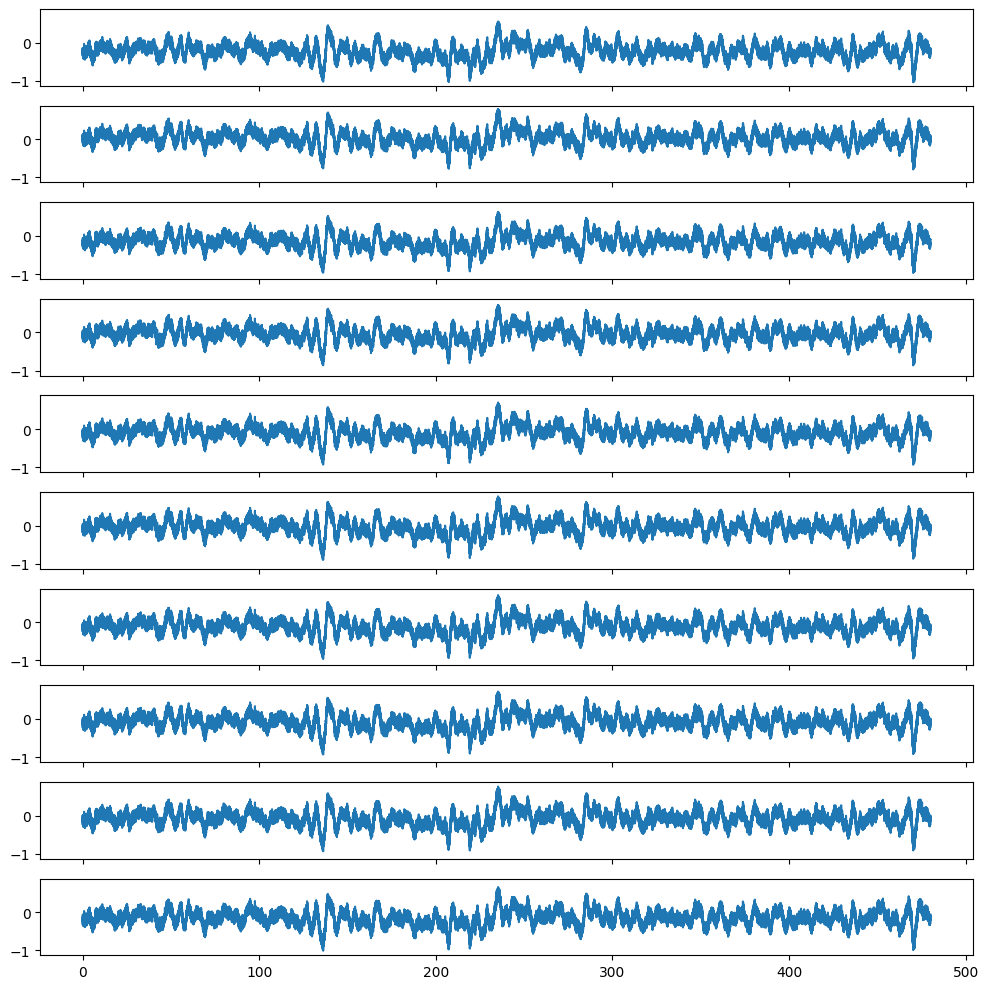

In [ ]:
fig, axes = plt.subplots(10, 1, figsize=(10, 10), sharex='all', sharey='all')
times = np.arange(df.MOp_lfp.values[0].shape[0]) / df.imec0_lfp_sfreq[0]
for chan, ax in zip(np.arange(10), axes):
    ax.plot(times, df.MOp_lfp.values[0][:, chan] * df.imec0_lfp_conversion[0] * 1000)

plt.tight_layout()


Text(0.5, 0.925, 'Motor cortex channels')

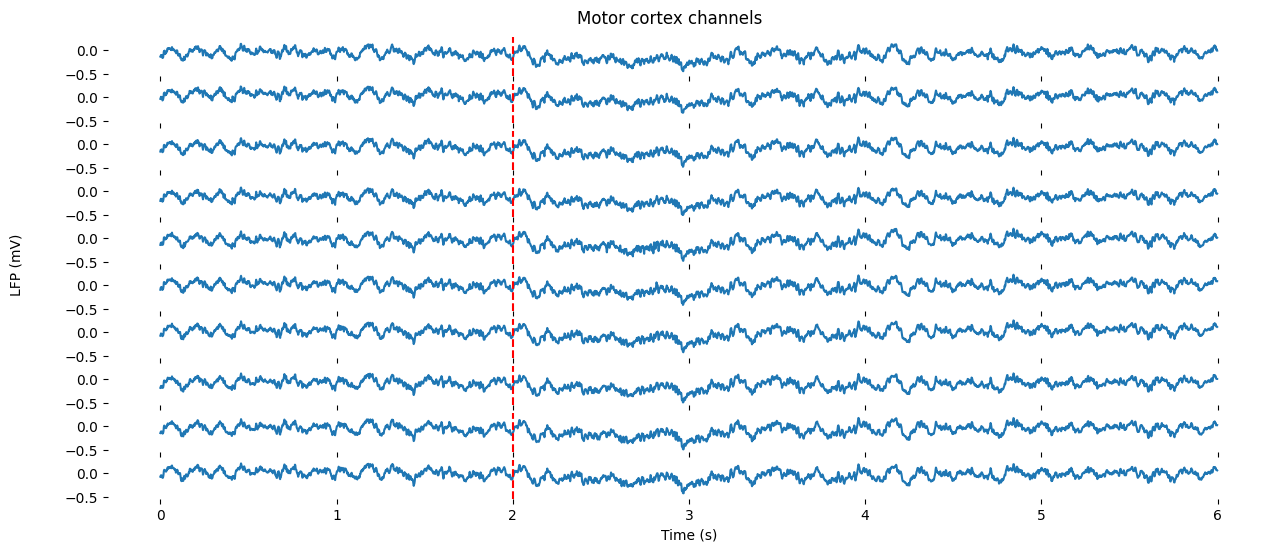

In [ ]:
fig, axes = plt.subplots(10, 1, figsize=(15, 6), sharex='all', sharey='all')
times = np.arange(df.MOp_lfp.values[2].shape[0]) / df.imec0_lfp_sfreq[0]
for chan, ax in zip(np.arange(80, 90), axes):
    ax.plot(times, df.MOp_lfp.values[2][:, chan] * df.imec0_lfp_conversion[0] * 1000)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.axvline(x=2, color='red', linestyle='dashed')

fig.text(0.06, 0.5, "LFP (mV)", va="center", rotation="vertical")
ax.set_xlabel('Time (s)')
plt.suptitle('Motor cortex channels', y=0.925)

# plt.tight_layout()


In [ ]:
df = handler.df.copy()
df = pyal.select_trials(df, df.trial_name == 'trial')


In [ ]:
fields = pyal.get_time_varying_fields(df, ref_field='MOp_lfp')
resample_factor = 5 # 100 hz to 500 hz
df["idx_sol_on"] = df["idx_sol_on"] * resample_factor


In [ ]:
fields

['SSp_lfp', 'all_lfp', 'VAL_lfp', 'MOp_lfp', 'CP_lfp']

In [ ]:
df.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'SSp_chan_best',
       'SSp_unit_guide', 'SSp_kslabel', 'SSp_spikes', 'all_chan_best',
       'all_unit_guide', 'all_kslabel', 'all_spikes', 'VAL_chan_best',
       'VAL_unit_guide', 'VAL_kslabel', 'VAL_spikes', 'MOp_chan_best',
       'MOp_unit_guide', 'MOp_kslabel', 'MOp_spikes', 'CP_chan_best',
       'CP_unit_guide', 'CP_kslabel', 'CP_spikes', 'imec0_lfp_sfreq',
       'imec0_lfp_conversion', 'SSp_lfp', 'all_lfp', 'VAL_lfp',
       'imec1_lfp_sfreq', 'imec1_lfp_conversion', 'MOp_lfp', 'CP_lfp',
       'SSp_rates', 'all_

In [ ]:
test_df = df[["idx_sol_on", "values_Sol_direction", "values_Sol_duration", "trial_id"] + fields]
test_df = test_df.rename(
    columns=lambda col: col[:-3] + "rates" if col.endswith("lfp") else col
)

In [ ]:
test_df

,idx_sol_on,values_Sol_direction,trial_id,SSp_rates,all_rates,VAL_rates,MOp_rates,CP_rates
0,1000,11,2,"[[-29.07802850795456, -12.004388796739551, -15...","[[0.4408681779149011, 8.977510864938202, -10.6...","[[0.7796538827189678, 17.030668411422727, 16.9...","[[-33.4371097642869, 20.682336873169707, -22.8...","[[-5.581018939626676, -0.1145768666416126, 12...."
1,1000,7,4,"[[13.344077569423673, 18.74754588165323, 20.38...","[[-11.860574092934751, 2.159672635435732, -22....","[[-1.0307239509728094, 7.797215637772301, 30.3...","[[-46.09693466620293, 13.502247496429657, -27....","[[-43.824151557466074, -30.246638818561813, -2..."
2,1000,1,6,"[[23.465231106796807, 35.704054947637154, 30.7...","[[-5.115943870165843, 7.872310727120255, -16.3...","[[5.829110371998049, 14.435942875401759, 32.82...","[[-45.84794654585839, 5.658599505546006, -33.1...","[[-38.77928499794774, -25.567326321475228, -26..."
3,1000,8,8,"[[20.608780744847188, 30.700274968419833, 24.6...","[[28.098296926506748, 34.24537154138801, 15.90...","[[1.5247780898917611, 13.815581128288184, 29.2...","[[-6.284695391817803, 47.05841802765427, 8.341...","[[0.14166098359570142, 16.56450552733562, 5.94..."
4,1000,4,10,"[[-38.37928816448687, -24.56449750795111, -31....","[[-9.146732945184494, 0.3726318256316794, -17....","[[2.5095726392110063, 7.530893028300273, 14.51...","[[-40.233378400933745, 11.847805601771388, -28...","[[-16.187962540214553, 2.2146363704286016, 1.4..."
...,...,...,...,...,...,...,...,...
355,1000,3.0,712,"[[23.178963806580523, 38.885411758368164, 31.7...","[[-36.37965505893636, -26.827724512130313, -26...","[[9.412344100923768, 18.143980672495896, 2.848...","[[-29.955501031113595, 12.673092417010631, -19...","[[-2.522538205110952, 6.4294133091253185, 14.0..."
356,1000,3.0,714,"[[24.058685935997733, 59.226722836196544, 38.0...","[[24.743578543792644, 40.92875948303461, 18.11...","[[-0.7314115668229106, 7.736636242885137, -2.2...","[[-6.1634981524405195, 45.62687525749275, 7.62...","[[5.4837872271733215, 21.41866287537453, 19.57..."
357,1000,0.0,716,"[[-14.924511302472018, -2.47784905908173, -9.0...","[[-29.183345504192037, -15.327186875466083, -2...","[[11.259960280835164, 20.63913859622417, 15.22...","[[-56.28022807470289, -4.233900607609065, -46....","[[-41.22373563152631, -33.375405858289106, -21..."
358,1000,10.0,718,"[[91.51936345783167, 119.21694418737918, 94.59...","[[-71.02413276197984, -74.27127447169005, -16....","[[41.3669123705506, 44.39229591795775, -14.846...","[[-73.58370103670963, -60.38014220169224, -77....","[[-41.606075929274944, -22.898689686195393, -2..."


In [ ]:
perturb_td = pyal.restrict_to_interval(test_df, 'idx_sol_on', rel_start = -1000, rel_end= 1000)  # 2 seconds to 2 seconds
targets = test_df.values_Sol_direction.values.tolist()
sfreq = df.imec0_lfp_sfreq[0]

In [ ]:
f, t, Sxx = scipy.signal.spectrogram(perturb_td.MOp_rates.values[3], fs=sfreq, axis=0, nperseg=int(sfreq * 0.6), noverlap=int(sfreq * 0.6 * 0.98))
print(t.shape, f.shape)

(284,) (151,)


## Spectrogram - MOp

In [ ]:
baseline = (0, 1)
bmask = (t >= baseline[0]) & (t <= baseline[1])

Sxx_across_trials = []
for trial in perturb_td.MOp_rates.values:
    f, t, Sxx = scipy.signal.spectrogram(trial, fs=sfreq, axis=0, nperseg=int(sfreq * 0.6), noverlap=int(sfreq * 0.6 * 0.98))
    Sxx = Sxx.mean(axis=1)
    P0 = Sxx[:, bmask].mean(axis=1, keepdims=True) 
    Sxx_across_trials.append(10*np.log10((Sxx + 1e-12) / (P0 + 1e-12)))



Sxx_across_trials_ = np.array(Sxx_across_trials)

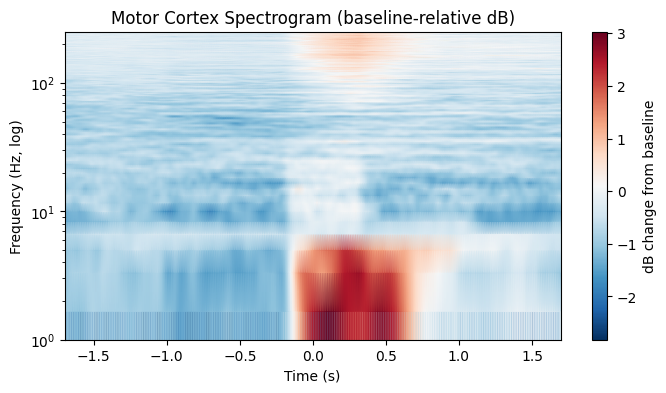

In [ ]:
plt.figure(figsize=(8,4))
plt.pcolormesh(t-2, f, Sxx_across_trials_.mean(axis=0), shading="gouraud", cmap="RdBu_r")
plt.yscale("log")
plt.colorbar(label="dB change from baseline")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz, log)")
plt.title("Motor Cortex Spectrogram (baseline-relative dB)")
plt.ylim(1, 250)
# plt.clim(-0.1, 20)

plt.show()

## Spectrogram - CP

In [ ]:
baseline = (0, 1)
bmask = (t >= baseline[0]) & (t <= baseline[1])

Sxx_across_trials = []
for trial in perturb_td.CP_rates.values:
    f, t, Sxx = scipy.signal.spectrogram(trial, fs=sfreq, axis=0, nperseg=int(sfreq * 0.6), noverlap=int(sfreq * 0.6 * 0.98))
    Sxx = Sxx.mean(axis=1)
    P0 = Sxx[:, bmask].mean(axis=1, keepdims=True) 
    Sxx_across_trials.append(10*np.log10((Sxx + 1e-12) / (P0 + 1e-12)))



Sxx_across_trials_ = np.array(Sxx_across_trials)

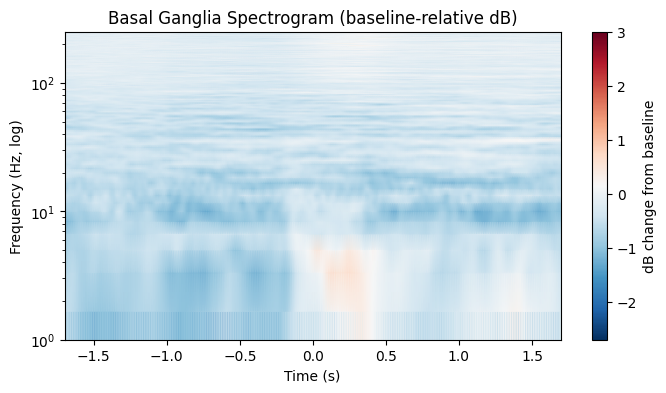

In [ ]:
plt.figure(figsize=(8,4))
plt.pcolormesh(t-2, f, Sxx_across_trials_.mean(axis=0), shading="gouraud", cmap="RdBu_r")
plt.yscale("log")
plt.colorbar(label="dB change from baseline")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz, log)")
plt.title("Basal Ganglia Spectrogram (baseline-relative dB)")
plt.ylim(1, 250)
plt.clim(-2.7, 3)

plt.show()

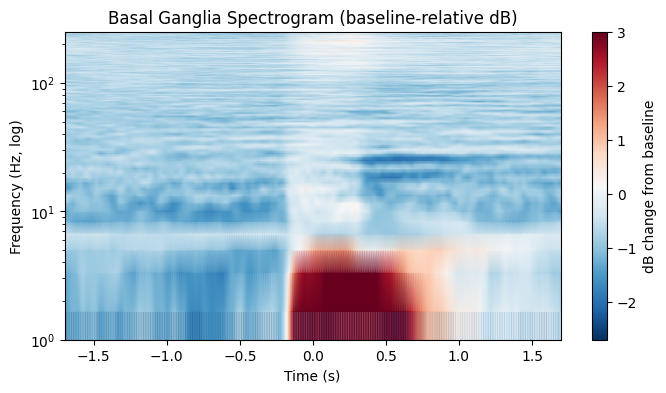

In [ ]:
baseline = (0, 1)
bmask = (t >= baseline[0]) & (t <= baseline[1])

Sxx_across_trials = []
for trial in perturb_td.SSp_rates.values:
    f, t, Sxx = scipy.signal.spectrogram(trial, fs=sfreq, axis=0, nperseg=int(sfreq * 0.6), noverlap=int(sfreq * 0.6 * 0.98))
    Sxx = Sxx.mean(axis=1)
    P0 = Sxx[:, bmask].mean(axis=1, keepdims=True) 
    Sxx_across_trials.append(10*np.log10((Sxx + 1e-12) / (P0 + 1e-12)))



Sxx_across_trials_ = np.array(Sxx_across_trials)

plt.figure(figsize=(8,4))
plt.pcolormesh(t-2, f, Sxx_across_trials_.mean(axis=0), shading="gouraud", cmap="RdBu_r")
plt.yscale("log")
plt.colorbar(label="dB change from baseline")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz, log)")
plt.title("Basal Ganglia Spectrogram (baseline-relative dB)")
plt.ylim(1, 250)
plt.clim(-2.7, 3)

plt.show()

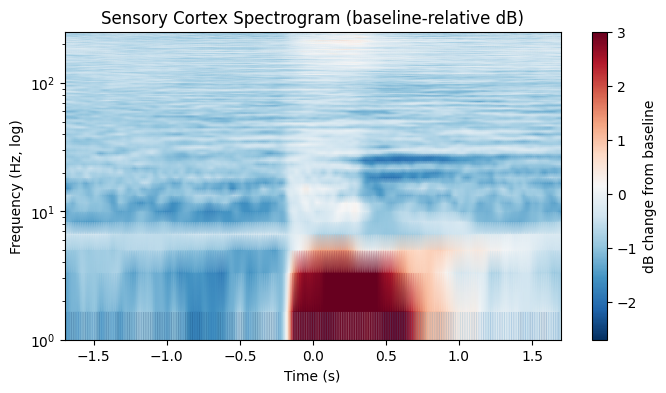

In [ ]:
plt.figure(figsize=(8,4))
plt.pcolormesh(t-2, f, Sxx_across_trials_.mean(axis=0), shading="gouraud", cmap="RdBu_r")
plt.yscale("log")
plt.colorbar(label="dB change from baseline")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz, log)")
plt.title("Sensory Cortex Spectrogram (baseline-relative dB)")
plt.ylim(1, 250)
plt.clim(-2.7, 3)


## Decoding

In [ ]:
np.stack(perturb_td.SSp_rates.values).shape

(360, 2001, 109)

In [ ]:
targets_dur = test_df.values_Sol_duration.values.tolist()
targets_dir = test_df.values_Sol_direction.values.tolist()


In [ ]:
perturb_td = pyal.restrict_to_interval(test_df, 'idx_sol_on', rel_start = -250, rel_end= 1000)  # 2 seconds to 2 seconds
targets = test_df.values_Sol_direction.values.tolist()
sfreq = df.imec0_lfp_sfreq[0]

In [ ]:
f, t, Sxx = scipy.signal.spectrogram(perturb_td[f"MOp_rates"].values[0], fs=sfreq, axis=0, nperseg=int(sfreq * 0.75), noverlap=int(sfreq * 0.75 * 0.98))
print(f.shape, t.shape)

(188,) (110,)


In [ ]:
data = {}
areas = ['MOp', 'CP', 'SSp']
baseline = (0, 1)
bmask = (t >= baseline[0]) & (t <= baseline[1])
for area in areas:
    Sxx_across_trials = []
    for trial in perturb_td[f"{area}_rates"].values:
        f, t, Sxx = scipy.signal.spectrogram(trial, fs=sfreq, axis=0, nperseg=int(sfreq * 0.75), noverlap=int(sfreq * 0.75 * 0.98))
        Sxx = Sxx.mean(axis=1)
        # P0 = Sxx[:, bmask].mean(axis=1, keepdims=True) 
        # Sxx_across_trials.append(10*np.log10((Sxx + 1e-12) / (P0 + 1e-12)))
        Sxx_across_trials.append(10*np.log10((Sxx + 1e-12)))
    
    data[area] = np.array(Sxx_across_trials)

In [ ]:
n_trials, n_freq, n_time = data["MOp"].shape
data["MOp"].reshape(n_trials, -1).shape

(360, 20680)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB

scores = {}
for area, data_ in data.items():
    scores[area] = cross_val_score(GaussianNB(), data_.reshape(n_trials, -1), targets_dir, scoring="accuracy", cv=5)
    print(f"{area} score: {scores[area].mean():.4f}")

MOp score: 0.1250
CP score: 0.0917
SSp score: 0.1417


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB

scores_dur = {}
for area, data_ in data.items():
    scores_dur[area] = cross_val_score(GaussianNB(), data_.reshape(n_trials, -1), targets_dur, scoring="accuracy", cv=5)
    print(f"{area} score: {scores_dur[area].mean():.4f}")

MOp score: 0.3278
CP score: 0.2500
SSp score: 0.3222


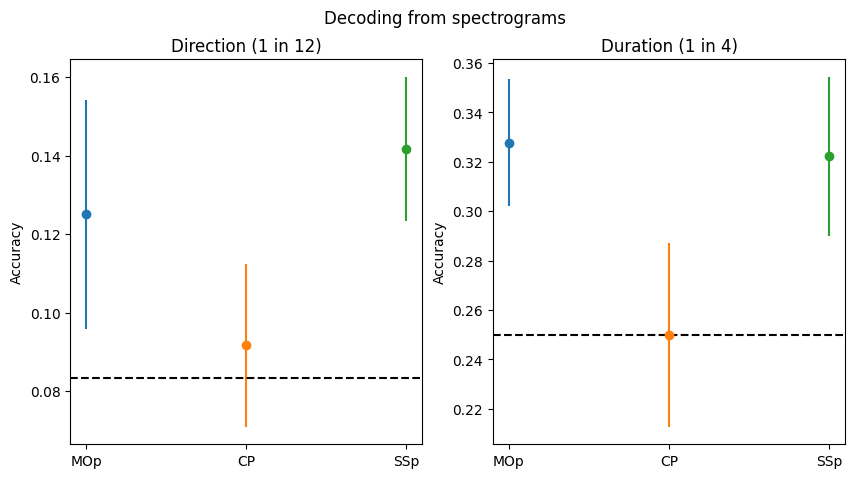

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].errorbar(x='MOp', y=scores["MOp"].mean(), yerr=scores['MOp'].std(), fmt='o', label='MOp')
axes[0].errorbar(x='CP', y=scores["CP"].mean(), yerr=scores['CP'].std(), fmt='o', label='CP')
axes[0].errorbar(x='SSp', y=scores["SSp"].mean(), yerr=scores['SSp'].std(), fmt='o', label='SSp')

axes[0].axhline(y=1/12, color='black', linestyle='dashed', label='chance')
# axes[0].legend()
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Direction (1 in 12)')

axes[1].errorbar(x='MOp', y=scores_dur["MOp"].mean(), yerr=scores_dur['MOp'].std(), fmt='o', label='MOp')
axes[1].errorbar(x='CP', y=scores_dur["CP"].mean(), yerr=scores_dur['CP'].std(), fmt='o', label='CP')
axes[1].errorbar(x='SSp', y=scores_dur["SSp"].mean(), yerr=scores_dur['SSp'].std(), fmt='o', label='SSp')

axes[1].axhline(y=1/4, color='black', linestyle='dashed', label='chance')
# axes[1].legend()
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Duration (1 in 4)')



plt.suptitle('Decoding from spectrograms')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# --- For classification ---
rf_clf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=None,        # depth of trees (None = full)
    random_state=42,       # reproducibility
    n_jobs=-1              # use all CPU cores
)
for area, data_ in data.items():
    score = cross_val_score(rf_clf, data_.reshape(n_trials, -1), targets, scoring="accuracy", cv=5)
    print(f"{area} score: {score.mean():.4f}")

MOp score: 0.3028
CP score: 0.2806


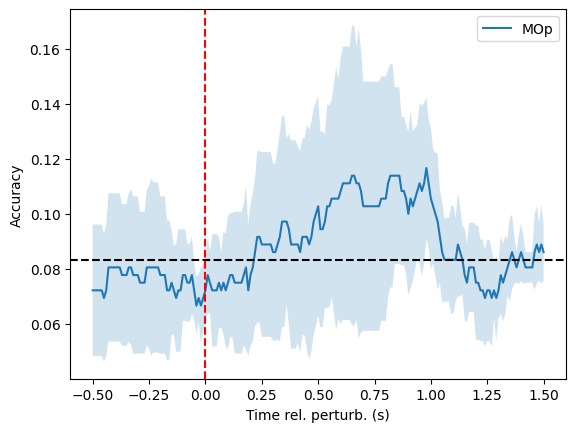

In [ ]:
fig, ax = plt.subplots()
line, _ = vizutils.shaded_errorbar(ax, times-1, scores, 
                                   errorStat=np.std, label='MOp')


ax.axvline(x=0, color='r', linestyle='dashed')
ax.axhline(y=1/12, color='k', linestyle='dashed')
ax.set_xlabel('Time rel. perturb. (s)')
ax.set_ylabel('Accuracy')
# ax.set_ylim(0, 0.5)
ax.legend()
# ax.set_xlim(0, 0.5)
# ax.set_title(f'{handler.session}. {title}')

In [ ]:
def get_psd(signal, fs, nperseg=None, noverlap=None):
    """computes psd. Expects time axis to be in axis 1

    Args:
        signal (_type_): _description_
        fs (_type_): _description_
        nperseg (_type_, optional): _description_. Defaults to None.
        noverlap (_type_, optional): _description_. Defaults to None.
    """
    return scipy.signal.welch(signal, fs=fs, nperseg=nperseg, noverlap=noverlap, axis=0)


def plot_psd(freqs, psd, title="Power Spectral Density", xlim=None, ylim=None):
    plt.figure(figsize=(8, 4))
    plt.semilogy(freqs, psd.mean(axis=-1), lw=2)
    plt.fill_between(freqs, psd.mean(axis=-1) - psd.std(axis=-1), psd.mean(axis=-1) + psd.std(axis=-1),
                 color="gray", alpha=0.3, label="±1 std")
    plt.ylabel("PSD (v**2/HZ)")
    plt.xlabel("Frequency (Hz)")
    plt.title(title)

    

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def quick_psd(signal, fs, title="Power Spectral Density", xlim=None, ylim=None, nperseg=None, noverlap=None):
    """
    Quick look at PSD of a brain signal using Welch's method.
    Units: (signal_unit^2 / Hz)
    """
    freqs, psd = get_psd(signal, fs=fs, nperseg=nperseg, noverlap=noverlap)  # 2-second windows

    plt.figure(figsize=(8, 4))
    plt.semilogy(freqs, psd.mean(axis=-1), lw=2)
    plt.fill_between(freqs, psd.mean(axis=-1) - psd.std(axis=-1), psd.mean(axis=-1) + psd.std(axis=-1),
                 color="gray", alpha=0.3, label="±1 std")
    plt.ylabel("PSD (v**2/HZ)")
    plt.xlabel("Frequency (Hz)")
    plt.title(title)

    

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
df.MOp_lfp.values[2].shape

(3000, 134)

In [ ]:
freqs.shape

(129,)

In [ ]:
freqs, psd = get_psd(df.MOp_lfp.values[2], fs=500)

In [ ]:
np.concatenate(df.MOp_lfp.values).shape

(2070000, 134)

In [ ]:
fs = df.imec0_lfp_sfreq[0]
nperseg=int(fs * 30)
# nperseg = None
noverlap = int(nperseg * 0.75)
# noverlap = None
freqs, psd = get_psd(np.concatenate(df.MOp_lfp.values)*df.imec0_lfp_conversion.values[0], fs=fs, nperseg=nperseg, noverlap=noverlap)


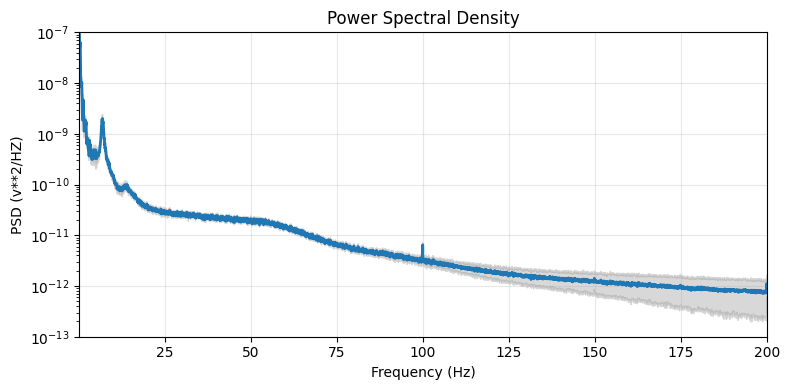

In [ ]:
plot_psd(freqs, psd,  xlim=(0.1, 200), ylim=(1e-13, 1e-7))

ValueError: x and y must have same first dimension, but have shapes (501,) and (134,)

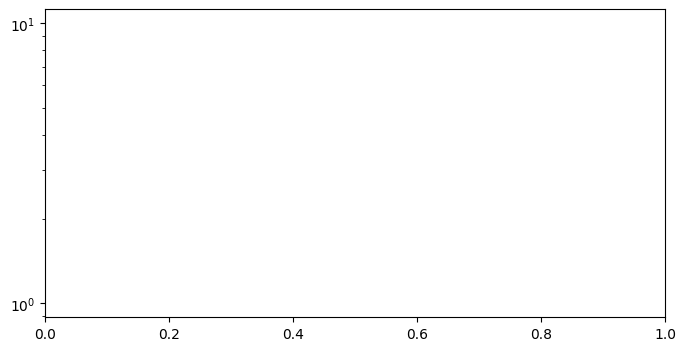

In [ ]:
fs = df.imec0_lfp_sfreq[0]
nperseg=fs*2
noverlap = int(nperseg * 0.9)
quick_psd(df.MOp_lfp.values[2] * df.imec0_lfp_conversion.values[0], fs=fs, nperseg=nperseg, noverlap=noverlap)

In [ ]:
# Loading raw lf file to check

import numpy as np
import json

def read_spikeglx_meta(meta_file):
    """Parse SpikeGLX .meta file into a dict."""
    meta = {}
    with open(meta_file, 'r') as f:
        for line in f:
            if '=' in line:
                key, val = line.strip().split('=', 1)
                meta[key] = val
    return meta

def load_lfp(lf_bin, lf_meta, to_uv=True):
    """
    Load LFP data from Neuropixels lf.bin + meta.

    Parameters
    ----------
    lf_bin : str
        Path to lf.bin file.
    lf_meta : str
        Path to lf.meta file.
    to_uv : bool
        If True, convert to microvolts (µV). Otherwise, return in Volts.

    Returns
    -------
    data : ndarray, shape (n_samples, n_channels)
        LFP data in µV (or V).
    fs : float
        Sampling frequency in Hz (should be ~2500 Hz).
    """
    meta = read_spikeglx_meta(lf_meta)
    n_channels = int(meta["nSavedChans"])
    fs = float(meta["imSampRate"])
    n_samples = int(np.fromfile(lf_bin, dtype=np.int16).size // n_channels)

    # conversion factor from int16 to volts
    imMaxInt = float(meta["imMaxInt"])
    imAiRangeMax = float(meta["imAiRangeMax"])
    conv_factor = imAiRangeMax / imMaxInt  # Volts per int16

    # load raw int16 and reshape
    raw = np.fromfile(lf_bin, dtype=np.int16).reshape(n_samples, n_channels)

    data = raw * conv_factor
    if to_uv:
        data *= 1e6  # convert V → µV

    return data, fs


(10425581, 385)
Sampling rate: 2500.0 Hz


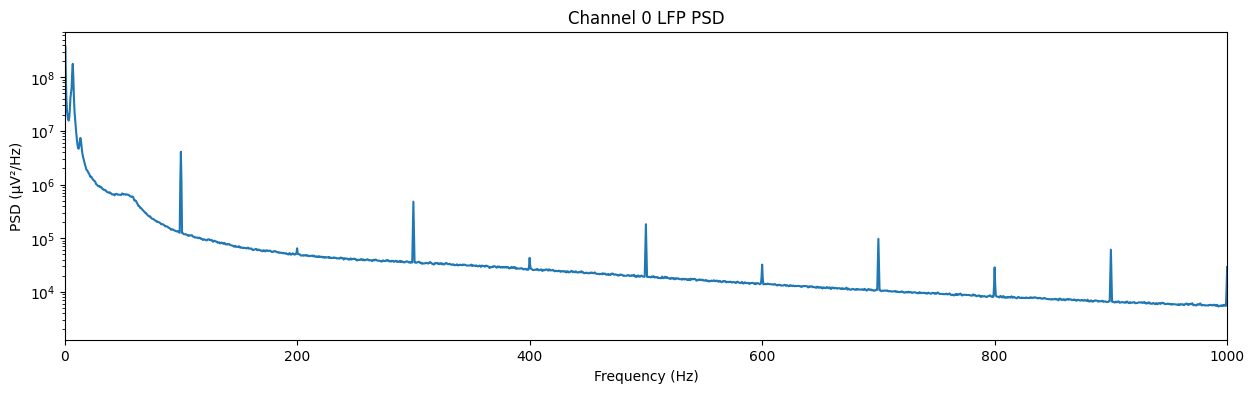

In [ ]:
lf_bin = "/data/bnd-data/raw/M062/M062_2025_03_19_14_00/M062_2025_03_19_14_00_g0/M062_2025_03_19_14_00_g0_imec0/M062_2025_03_19_14_00_g0_t0.imec0.lf.bin"
lf_meta = "/data/bnd-data/raw/M062/M062_2025_03_19_14_00/M062_2025_03_19_14_00_g0/M062_2025_03_19_14_00_g0_imec0/M062_2025_03_19_14_00_g0_t0.imec0.lf.meta"

lfp, fs = load_lfp(lf_bin, lf_meta)

print(lfp.shape)   # (n_samples, n_channels)
print("Sampling rate:", fs, "Hz")

# Quick PSD check on first channel
from scipy.signal import welch
import matplotlib.pyplot as plt

f, Pxx = welch(lfp[:3425581, :], fs=fs, nperseg=fs*2, noverlap=fs*0.9, axis=0)
plt.figure(figsize=(15, 4))
plt.semilogy(f, Pxx.mean(axis=-1))
plt.xlim(0, 1000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (µV²/Hz)")
plt.title("Channel 0 LFP PSD")
plt.show()

# quick_psd(lfp[:, :3], fs=fs, nperseg=fs*60, xlim=(0, 100))


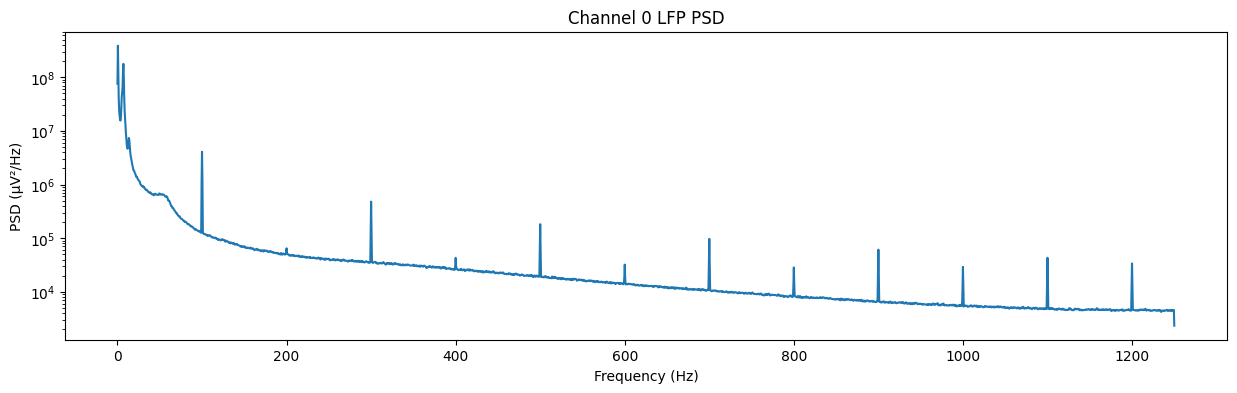

In [ ]:
plt.figure(figsize=(15, 4))
plt.semilogy(f, Pxx.mean(axis=-1))
# plt.xlim(0, 1250)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (µV²/Hz)")
plt.title("Channel 0 LFP PSD")
plt.show()

## Multiple frequency bands to decode

In [ ]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M062_2025_03_19_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field SSp_kslabel could not be converted to int.
array field all_kslabel could not be converted to int.
array field VAL_kslabel could not be converted to int.
array field MOp_kslabel could not be converted to int.
array field CP_kslabel could not be converted to int.
array field SSp_kslabel could not be converted to int.
array field all_kslabel could not be converted to int.
array field VAL_kslabel could not be converted to int.
array field MOp_kslabel could not be converted to int.
array field CP_kslabel could not be converted to int.
field idx_motion could not be converted to int.
field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to int.
arr

/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.86149584487535% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.86149584487535% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.86149584487535% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.86149584487535% of trials
  warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/

['SSp_spikes', 'all_spikes', 'VAL_spikes', 'MOp_spikes', 'CP_spikes']


/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/src/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(


Resulting SSp_spikes ephys data shape is (NxT): (95, 48000)
Resulting all_spikes ephys data shape is (NxT): (34, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (198, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (210, 48000)
Resulting CP_spikes ephys data shape is (NxT): (307, 48000)


In [ ]:
df = pyal.select_trials(df, df.trial_name == 'trial')
fields = pyal.get_time_varying_fields(df, ref_field='MOp_lfp')
resample_factor = 5 # 100 hz to 500 hz
df["idx_sol_on"] = df["idx_sol_on"] * resample_factor
test_df = df[["idx_sol_on", "values_Sol_direction", "values_Sol_duration", "trial_id"] + fields]
test_df = test_df.rename(
    columns=lambda col: col[:-3] + "rates" if col.endswith("lfp") else col
)

In [ ]:
perturb_td = pyal.restrict_to_interval(test_df, 'idx_sol_on', rel_start = -250, rel_end= 1000)  # -0.5 seconds to 2 seconds
targets = test_df.values_Sol_direction.values.tolist()
sfreq = df.imec0_lfp_sfreq[0]

In [ ]:
filtered_arr = dsp.sos_bandpass_filter(test_df.MOp_rates.values[0][:, :2], 500, (8, 12), 3)
power_arr = dsp.get_power_from_array(filtered_arr)

In [ ]:
data = {}
freqs = [
    ('delta', (0.5, 4)),
    ('theta', (4, 8)),
    ('alpha', (8, 12)),
    ('beta', (12, 30)),
    ('l_gamma', (30, 60)),
    ('h_gamma', (60, 245))
]
areas = ['MOp', 'CP', 'SSp']
for area in areas:
    print(f"Processing area: {area}")
    band_pass_power = {}
    for freq, freq_range in freqs:
        print(f"\tProcessing freq: {freq}")
        band_pass_power[freq] = []
        for trial in perturb_td[f"{area}_rates"].values:
            trial_power_signal = dsp.get_power_in_freq_range(
                trial,
                fs=500,
                freqs=freq_range,
                order=3
            )
            band_pass_power[freq].append(trial_power_signal)
        band_pass_power[freq] = np.array(band_pass_power[freq])
    data[area] = band_pass_power

Processing area: MOp
	Processing freq: delta
	Processing freq: theta
	Processing freq: alpha
	Processing freq: beta
	Processing freq: l_gamma
	Processing freq: h_gamma
Processing area: CP
	Processing freq: delta
	Processing freq: theta
	Processing freq: alpha
	Processing freq: beta
	Processing freq: l_gamma
	Processing freq: h_gamma
Processing area: SSp
	Processing freq: delta
	Processing freq: theta
	Processing freq: alpha
	Processing freq: beta
	Processing freq: l_gamma
	Processing freq: h_gamma


In [ ]:
data['MOp']["delta"].shape

(360, 1251, 134)

In [ ]:
perturb_td.MOp_rates.values[0].shape[0] / 500

2.502

Text(0.5, 1.0, 'Motor cortex sample trial. All chans')

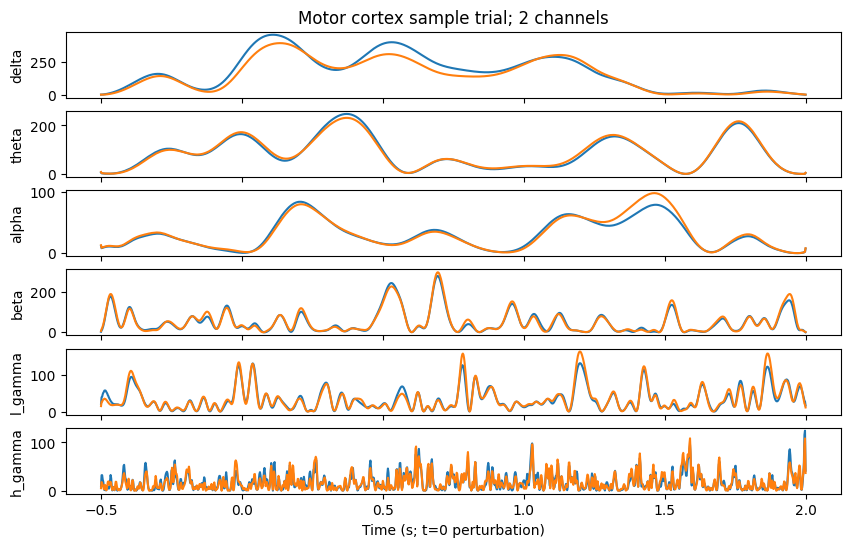

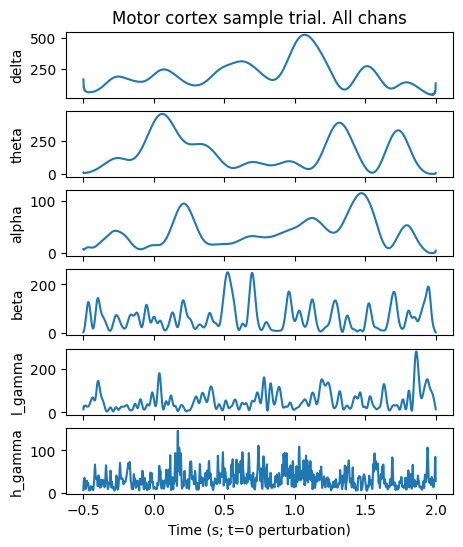

In [ ]:
fig, axes = plt.subplots(6, 1, sharex='all', figsize=(10, 6))
times = np.arange(start=0, stop=perturb_td.MOp_rates.values[0].shape[0]/500, step=1/500) - 0.5
area = 'MOp'
for ax, freq in zip(axes, data[area].keys()):
    ax.plot(times, data[area][freq][0, :, :2])
    ax.set_ylabel(freq)

ax.set_xlabel('Time (s; t=0 perturbation)')
axes[0].set_title('Motor cortex sample trial; 2 channels')

fig, axes = plt.subplots(6, 1, sharex='all', figsize=(5, 6))
times = np.arange(start=0, stop=perturb_td.MOp_rates.values[0].shape[0]/500, step=1/500) - 0.5
for ax, freq in zip(axes, data[area].keys()):
    ax.plot(times, data[area][freq][0, :, :].mean(axis=-1))
    ax.set_ylabel(freq)

ax.set_xlabel('Time (s; t=0 perturbation)')
axes[0].set_title('Motor cortex sample trial. All chans')

Text(0.5, 1.0, 'Basal ganglia sample trial. All chans')

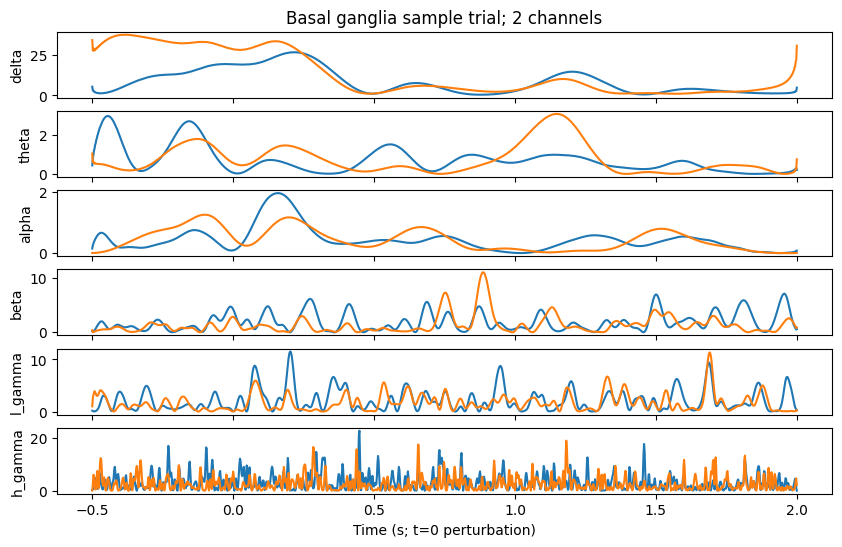

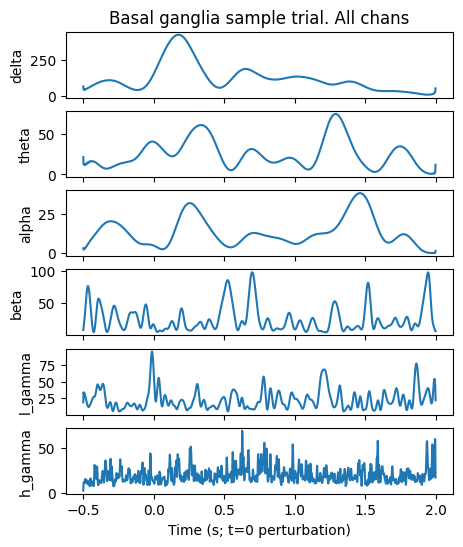

In [ ]:
fig, axes = plt.subplots(6, 1, sharex='all', figsize=(10, 6))
times = np.arange(start=0, stop=perturb_td.MOp_rates.values[0].shape[0]/500, step=1/500) - 0.5
area = 'CP'
for ax, freq in zip(axes, data[area].keys()):
    ax.plot(times, data[area][freq][0, :, :2])
    ax.set_ylabel(freq)

ax.set_xlabel('Time (s; t=0 perturbation)')
axes[0].set_title('Basal ganglia sample trial; 2 channels')

fig, axes = plt.subplots(6, 1, sharex='all', figsize=(5, 6))
times = np.arange(start=0, stop=perturb_td.MOp_rates.values[0].shape[0]/500, step=1/500) - 0.5
for ax, freq in zip(axes, data[area].keys()):
    ax.plot(times, data[area][freq][0, :, :].mean(axis=-1))
    ax.set_ylabel(freq)

ax.set_xlabel('Time (s; t=0 perturbation)')
axes[0].set_title('Basal ganglia sample trial. All chans')

In [ ]:
data[area][freq].shape

(360, 1251, 230)

In [ ]:
n_trials = len(targets)

In [ ]:
data[area][freq].reshape(n_trials, -1).shape

(360, 167634)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB

targets_dir = test_df.values_Sol_direction.values.tolist()
targets_dur = test_df.values_Sol_duration.values.tolist()


scores_dir = {}
for area in data.keys():
    scores_dir[area] = {}
    for freq in data[area].keys():
        scores_dir[area][freq] = cross_val_score(GaussianNB(), data[area][freq].reshape(n_trials, -1), targets_dir, scoring="accuracy", cv=5)
        print(f"{area} {freq} score: {scores_dir[area][freq].mean():.4f}")

scores_dur = {}
for area in data.keys():
    scores_dur[area] = {}
    for freq in data[area].keys():
        scores_dur[area][freq] = cross_val_score(GaussianNB(), data[area][freq].reshape(n_trials, -1), targets_dur, scoring="accuracy", cv=5)
        print(f"{area} {freq} score: {scores_dur[area][freq].mean():.4f}")

MOp delta score: 0.0750
MOp theta score: 0.0833
MOp alpha score: 0.0806
MOp beta score: 0.0861
MOp l_gamma score: 0.0917
MOp h_gamma score: 0.1222
CP delta score: 0.0750
CP theta score: 0.0806
CP alpha score: 0.0611
CP beta score: 0.0778
CP l_gamma score: 0.0917
CP h_gamma score: 0.1000
SSp delta score: 0.1000
SSp theta score: 0.0833
SSp alpha score: 0.0889
SSp beta score: 0.1000
SSp l_gamma score: 0.0944
SSp h_gamma score: 0.0944
MOp delta score: 0.2500
MOp theta score: 0.2361
MOp alpha score: 0.2556
MOp beta score: 0.2611
MOp l_gamma score: 0.2361
MOp h_gamma score: 0.2389
CP delta score: 0.2444
CP theta score: 0.2500
CP alpha score: 0.2611
CP beta score: 0.2500
CP l_gamma score: 0.2194
CP h_gamma score: 0.2583
SSp delta score: 0.2500
SSp theta score: 0.2472
SSp alpha score: 0.2778
SSp beta score: 0.2722
SSp l_gamma score: 0.2444
SSp h_gamma score: 0.2472


/tmp/ipykernel_3827650/710788291.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability
/tmp/ipykernel_3827650/710788291.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability
/tmp/ipykernel_3827650/710788291.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability


Text(0, 0.5, 'Accuracy - Pertub. Direction')

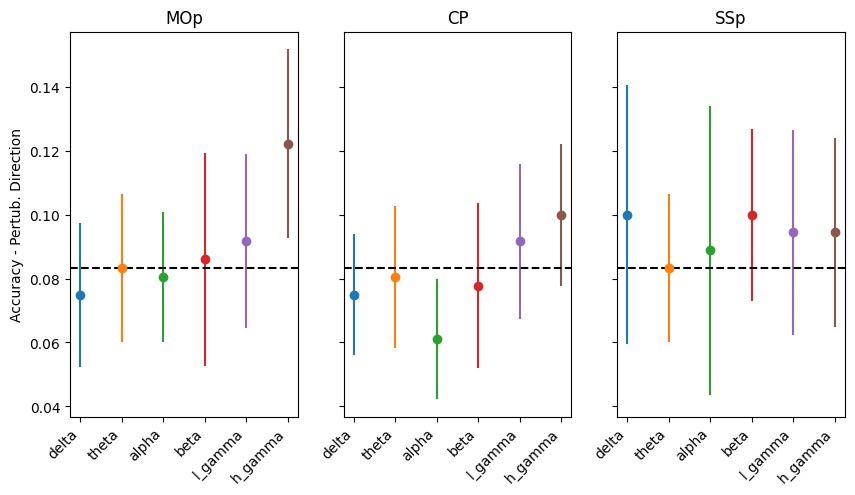

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharex='all', sharey='all')
for area, ax in zip(scores_dir.keys(), axes):
    for freq in scores_dir[area].keys():
        ax.errorbar(x=freq, y=scores_dir[area][freq].mean(), yerr=scores_dir[area][freq].std(), fmt='o')
    ax.axhline(y=1/12, color='black', linestyle='dashed', label='chance')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability
    ax.set_title(area)
axes[0].set_ylabel('Accuracy - Pertub. Direction')



/tmp/ipykernel_3827650/1543095902.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability
/tmp/ipykernel_3827650/1543095902.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability
/tmp/ipykernel_3827650/1543095902.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability


Text(0, 0.5, 'Accuracy - Pertub. Duration')

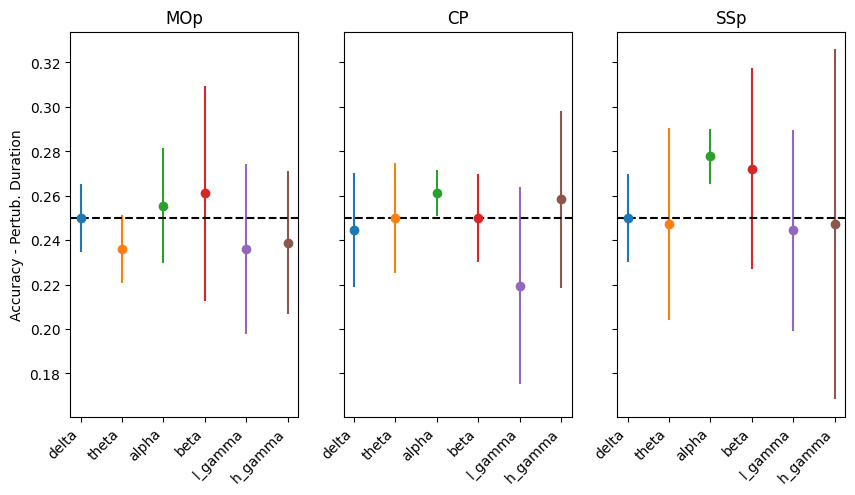

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharex='all', sharey='all')
for area, ax in zip(scores_dur.keys(), axes):
    for freq in scores_dur[area].keys():
        ax.errorbar(x=freq, y=scores_dur[area][freq].mean(), yerr=scores_dur[area][freq].std(), fmt='o')
    ax.axhline(y=1/4, color='black', linestyle='dashed', label='chance')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability
    ax.set_title(area)
axes[0].set_ylabel('Accuracy - Pertub. Duration')



## New loading format

In [ ]:
data_dir='/data/bnd-data/raw/'
session='M062_2025_03_19_14_00'
df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)


Using matlab v7.3 format


KeyboardInterrupt: 

In [ ]:
import hdf5storage

mat = hdf5storage.loadmat('/data/bnd-data/raw/M062/M062_2025_03_19_14_00/M062_2025_03_19_14_00_pyaldata.mat')

KeyboardInterrupt: 

In [ ]:
import pandas as pd
df = pd.DataFrame(mat['pyaldata'])


In [ ]:
df.animal

0    M062
1    M062
2    M062
3    M062
4    M062
5    M062
6    M062
Name: animal, dtype: object

In [ ]:
import numpy as np
import pandas as pd
import hdf5storage

# Example DataFrame
test_df = pd.DataFrame({
    "animal": ["ratA", "ratB", "ratC"],
    "session": ["day1", "day2", "day3"],
    "firing_rate": [23.4, 30.1, 28.9]
}).copy()

# --- 1. Sanitize all string columns ---
for col in test_df.columns:
    if test_df[col].dtype == object or pd.api.types.is_string_dtype(test_df[col]):
        test_df[col] = test_df[col].fillna("").astype(str)
        # Convert all to np.str_ explicitly
        test_df[col] = test_df[col].apply(lambda x: np.str_(x))

# --- 2. Build list of pure Python dicts ---
records = []
for _, row in test_df.iterrows():
    rec = {}
    for col in test_df.columns:
        val = row[col]
        if isinstance(val, str) or isinstance(val, np.str_):
            rec[col] = np.str_(val)  # ensure pure MATLAB string
        elif pd.isna(val):
            rec[col] = np.nan
        else:
            rec[col] = val
    records.append(rec)

# --- 3. Save with hdf5storage ---
hdf5storage.savemat(
    "pyaldata_fixed.mat",
    {"pyaldata": records},
    format="7.3",
    store_python_metadata=True,
)

print("✅ Saved successfully")


✅ Saved successfully


In [ ]:
data = hdf5storage.loadmat("pyaldata_fixed.mat")
records = data["pyaldata"]
print(records[0])           # should show the string fields!
df_loaded = pd.DataFrame(records)
print(df_loaded)


{'animal': 'ratA', 'session': 'day1', 'firing_rate': 23.4}
  animal session  firing_rate
0   ratA    day1         23.4
1   ratB    day2         30.1
2   ratC    day3         28.9


# Increasing statistical power

In [51]:
file = '/data/bnd-data/raw/M062/M062_2025_03_19_14_00/M062_2025_03_19_14_00_pyaldata.pkl.gz'
df_loaded = pyal.load_pyaldata_from_pkl(file)
df_loaded = dsp.preprocess(df_loaded, combine_time_bins=False)

/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.86149584487535% of trials
  warnings.warn(


['all_spikes', 'VAL_spikes', 'SSp_spikes', 'MOp_spikes', 'CP_spikes']
Resulting all_spikes ephys data shape is (NxT): (34, 600)
Resulting VAL_spikes ephys data shape is (NxT): (198, 600)
Resulting SSp_spikes ephys data shape is (NxT): (95, 600)
Resulting MOp_spikes ephys data shape is (NxT): (210, 600)
Resulting CP_spikes ephys data shape is (NxT): (307, 600)


In [206]:
# Clean up trial
df = pyal.select_trials(df_loaded, df_loaded.trial_name == 'trial')
# df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
sfreq = df.imec0_lfp_sfreq.values[0]  # 1250 Hz
resample_factor = sfreq * 0.01
df["idx_sol_on"] = df["idx_sol_on"] * resample_factor
df["trial_length"] = df["trial_length"] * resample_factor


In [207]:
# Generate lfp trial data
fields = pyal.get_time_varying_fields(df, 'MOp_lfp')
df_lfp = df[["idx_sol_on", "values_Sol_direction", "values_Sol_duration", "trial_id"] + fields]
df_lfp = df_lfp.rename(
    columns=lambda col: col[:-3] + "rates" if col.endswith("lfp") else col
)

In [208]:
# Crop trial_data
pre_seconds = -0.5
post_seconds = 1
perturb_td = pyal.restrict_to_interval(
    df_lfp,
    'idx_sol_on',
    rel_start = int(pre_seconds * sfreq),
    rel_end= int(post_seconds * sfreq),
)



In [170]:
perturb_td.shape

(360, 9)

In [209]:
data = {}
freqs = [
    ('delta', (0.5, 4), 2),
    ('theta', (4, 8), 2),
    ('alpha', (8, 12), 3),
    ('beta', (12, 30), 3),
    ('l_gamma', (30, 60), 4),
    ('h_gamma', (60, 250), 4),
    ('MUA', (250, 600), 4)
]
areas = ['MOp', 'CP', 'SSp']
for area in areas:
    print(f"Processing area: {area}")
    band_pass_power = {}
    for freq, freq_range, order in tqdm(freqs):
        # print(f"\tProcessing freq: {freq}")
        band_pass_power[freq] = []
        for trial in perturb_td[f"{area}_rates"].values:
            trial_power_signal = dsp.get_power_in_freq_range(
                trial,
                fs=sfreq,
                freqs=freq_range,
                order=order
            )
            band_pass_power[freq].append(trial_power_signal)
        band_pass_power[freq] = np.array(band_pass_power[freq])
    data[area] = band_pass_power

Processing area: MOp


100%|██████████| 7/7 [00:21<00:00,  3.11s/it]


Processing area: CP


100%|██████████| 7/7 [00:38<00:00,  5.51s/it]


Processing area: SSp


100%|██████████| 7/7 [00:18<00:00,  2.60s/it]


In [210]:
# Assign data to dataframe
for area in areas:
    for freq, _, _ in freqs:
        perturb_td[f"{area}_{freq}"] = np.array
        for idx, _ in perturb_td.iterrows():
            # print(idx)
            trial = data[area][freq][idx]
            perturb_td[f"{area}_{freq}"].at[idx] = trial

In [211]:
perturb_td.columns

Index(['idx_sol_on', 'values_Sol_direction', 'values_Sol_duration', 'trial_id',
       'all_rates', 'VAL_rates', 'SSp_rates', 'MOp_rates', 'CP_rates',
       'MOp_delta', 'MOp_theta', 'MOp_alpha', 'MOp_beta', 'MOp_l_gamma',
       'MOp_h_gamma', 'MOp_MUA', 'CP_delta', 'CP_theta', 'CP_alpha', 'CP_beta',
       'CP_l_gamma', 'CP_h_gamma', 'CP_MUA', 'SSp_delta', 'SSp_theta',
       'SSp_alpha', 'SSp_beta', 'SSp_l_gamma', 'SSp_h_gamma', 'SSp_MUA'],
      dtype='object')

Text(0.5, 1.0, 'Basal ganglia sample trial. All chans')

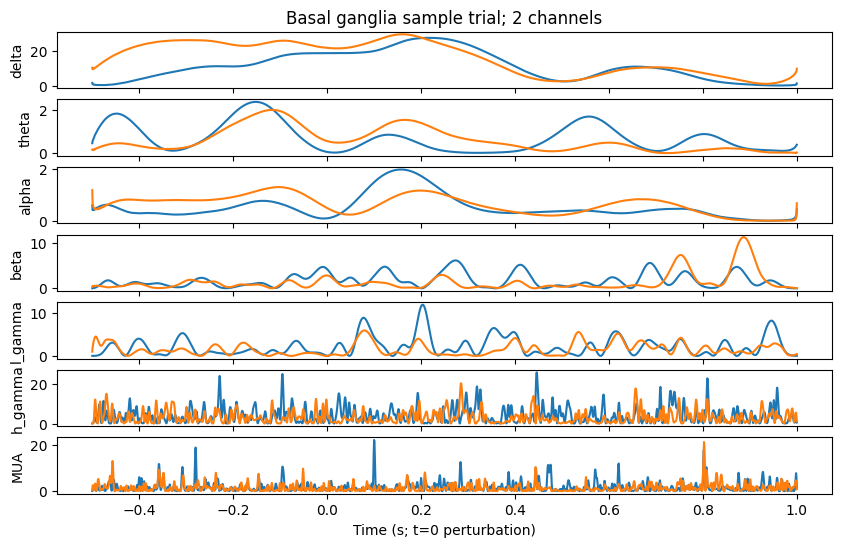

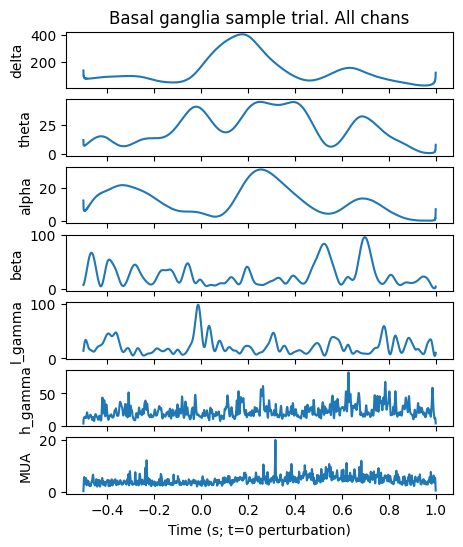

In [212]:
fig, axes = plt.subplots(7, 1, sharex='all', figsize=(10, 6))
times = np.arange(start=0, stop=perturb_td.MOp_rates.values[0].shape[0]/1250, step=1/1250) - 0.5
area = 'CP'
for ax, freq in zip(axes, data[area].keys()):
    ax.plot(times, data[area][freq][0, :, :2])
    ax.set_ylabel(freq)

ax.set_xlabel('Time (s; t=0 perturbation)')
axes[0].set_title('Basal ganglia sample trial; 2 channels')

fig, axes = plt.subplots(7, 1, sharex='all', figsize=(5, 6))
times = np.arange(start=0, stop=perturb_td.MOp_rates.values[0].shape[0]/1250, step=1/1250) - 0.5
for ax, freq in zip(axes, data[area].keys()):
    ax.plot(times, data[area][freq][0, :, :].mean(axis=-1))
    ax.set_ylabel(freq)

ax.set_xlabel('Time (s; t=0 perturbation)')
axes[0].set_title('Basal ganglia sample trial. All chans')

In [120]:
data[area][freq].shape

(264, 1876, 230)

In [ ]:
targets_dir = perturb_td.values_Sol_direction.values.tolist()
targets_dur = perturb_td.values_Sol_duration.values.tolist()
n_trials, n_freq, n_time = data["MOp"].shape


scores_dir = {}
for area in data.keys():
    scores_dir[area] = {}
    for freq in data[area].keys():
        scores_dir[area][freq] = cross_val_score(GaussianNB(), data[area][freq].reshape(n_trials, -1), targets_dir, scoring="accuracy", cv=5)
        print(f"{area} {freq} score: {scores_dir[area][freq].mean():.4f}")

scores_dur = {}
for area in data.keys():
    scores_dur[area] = {}
    for freq in data[area].keys():
        scores_dur[area][freq] = cross_val_score(GaussianNB(), data[area][freq].reshape(n_trials, -1), targets_dur, scoring="accuracy", cv=5)
        print(f"{area} {freq} score: {scores_dur[area][freq].mean():.4f}")

MOp delta score: 0.1022
MOp theta score: 0.1061
MOp alpha score: 0.1025
MOp beta score: 0.0985
MOp l_gamma score: 0.0644
MOp h_gamma score: 0.0985
MOp MUA score: 0.1136
CP delta score: 0.1060
CP theta score: 0.0870
CP alpha score: 0.0911
CP beta score: 0.0757
CP l_gamma score: 0.1136
CP h_gamma score: 0.0795
CP MUA score: 0.1590
SSp delta score: 0.1061
SSp theta score: 0.0987
SSp alpha score: 0.1060
SSp beta score: 0.0984
SSp l_gamma score: 0.0721
SSp h_gamma score: 0.0832
SSp MUA score: 0.0948
MOp delta score: 0.2461
MOp theta score: 0.3028
MOp alpha score: 0.2614
MOp beta score: 0.2762
MOp l_gamma score: 0.2274
MOp h_gamma score: 0.2504
MOp MUA score: 0.2573
CP delta score: 0.2348
CP theta score: 0.2689
CP alpha score: 0.2578
CP beta score: 0.2464
CP l_gamma score: 0.2390
CP h_gamma score: 0.1971
CP MUA score: 0.2691
SSp delta score: 0.2726
SSp theta score: 0.2464
SSp alpha score: 0.2801
SSp beta score: 0.2538
SSp l_gamma score: 0.2540
SSp h_gamma score: 0.2840
SSp MUA score: 0.2801


/tmp/ipykernel_36769/710788291.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability
/tmp/ipykernel_36769/710788291.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability
/tmp/ipykernel_36769/710788291.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability


Text(0, 0.5, 'Accuracy - Pertub. Direction')

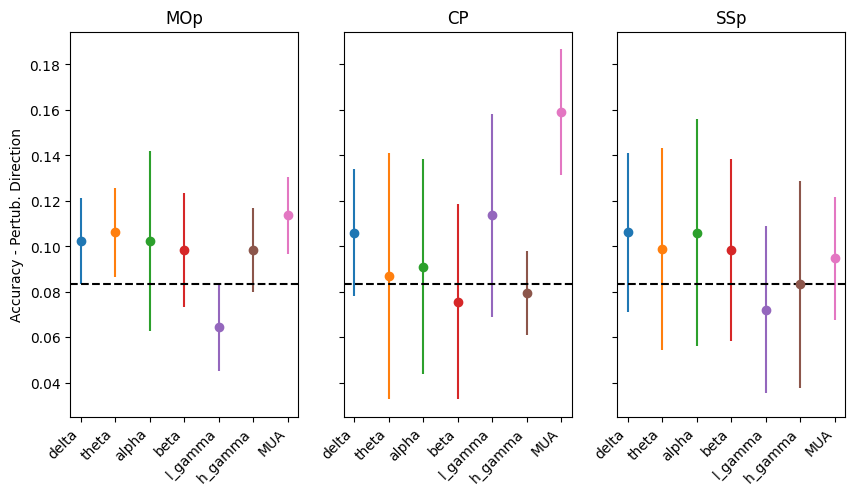

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharex='all', sharey='all')
for area, ax in zip(scores_dir.keys(), axes):
    for freq in scores_dir[area].keys():
        ax.errorbar(x=freq, y=scores_dir[area][freq].mean(), yerr=scores_dir[area][freq].std(), fmt='o')
    ax.axhline(y=1/12, color='black', linestyle='dashed', label='chance')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # align right for readability
    ax.set_title(area)
axes[0].set_ylabel('Accuracy - Pertub. Direction')



## Multiple seeds

In [216]:
n_trials, n_freq, n_time = np.stack(perturb_td_["MOp_alpha"].values).shape


In [218]:
# Balance classes
scores_dir, scores_dur = {}, {}
for area in areas:
    scores_dir[area] = {}
    for freq, _, _ in freqs:
        scores_dir[area][freq] = []
        print(f"Processing {area}, {freq}")
        for random_state in tqdm(range(20)):
            perturb_td_ = dt.balance_classes(perturb_td, 'values_Sol_direction', 
                                            random_state = random_state)
            n_trials, n_freq, n_time = np.stack(perturb_td_["MOp_alpha"].values).shape

            targets_dir = perturb_td_.values_Sol_direction.values.tolist()
            score = cross_val_score(GaussianNB(), 
                                    np.stack(perturb_td_[f"{area}_{freq}"].values).reshape(n_trials, -1), 
                                    targets_dir, scoring="accuracy", cv=5)
            scores_dir[area][freq].append(score.mean())
        scores_dir[area][freq] = np.array(scores_dir[area][freq])

Processing MOp, delta


100%|██████████| 20/20 [01:27<00:00,  4.39s/it]


Processing MOp, theta


100%|██████████| 20/20 [01:27<00:00,  4.37s/it]


Processing MOp, alpha


...

Processing CP, MUA


100%|██████████| 20/20 [02:37<00:00,  7.89s/it]


Processing SSp, delta


 15%|█▌        | 3/20 [00:11<01:06,  3.92s/it]


KeyboardInterrupt: 

In [221]:
scores_dir[area]

{'delta': array([0.08730044, 0.08352685, 0.08323657, 0.11364296, 0.07597968,
        0.09100145, 0.09455733, 0.0682148 , 0.09092888, 0.07198839,
        0.06814224, 0.06806967, 0.0756894 , 0.09840348, 0.09092888,
        0.10979681, 0.12104499, 0.0796807 , 0.05297533, 0.07953556]),
 'theta': array([0.08359942, 0.05682148, 0.0871553 , 0.07198839, 0.07206096,
        0.0682148 , 0.07590711, 0.06814224, 0.08701016, 0.07184325,
        0.0682148 , 0.0756894 , 0.11342525, 0.05682148, 0.06059507,
        0.08722787, 0.06066763, 0.08722787, 0.08323657, 0.10224964]),
 'alpha': array([0.09448476, 0.0871553 , 0.05689405, 0.08338171, 0.06066763,
        0.09862119, 0.06814224, 0.09092888, 0.09085631, 0.0756894 ,
        0.09063861, 0.07576197, 0.05283019, 0.06436865, 0.11357039,
        0.11357039, 0.04927431, 0.08708273, 0.09448476, 0.08330914]),
 'beta': array([0.06059507, 0.06458636, 0.05696662, 0.0756894 , 0.07191582,
        0.06088534, 0.0605225 , 0.08338171, 0.03788099, 0.04934688,
       

[Text(0, 0, 'delta'),
 Text(1, 0, 'theta'),
 Text(2, 0, 'alpha'),
 Text(3, 0, 'beta'),
 Text(4, 0, 'l_gamma'),
 Text(5, 0, 'h_gamma'),
 Text(6, 0, 'MUA')]

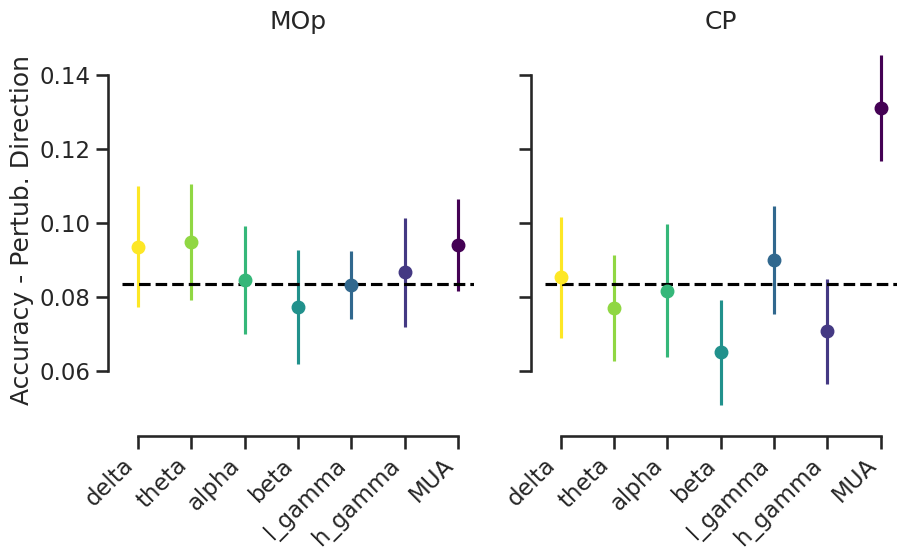

In [232]:
with vizutils.apply_plot_style():
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex='all', sharey='all')
    colors_ = plt.cm.viridis(np.linspace(1, 0, len(scores_dir['MOp'].keys())))

    for area, ax in zip(['MOp', 'CP'], axes):
        for freq, color in zip(scores_dir[area].keys(), colors_):
            ax.errorbar(x=freq, y=scores_dir[area][freq].mean(), yerr=scores_dir[area][freq].std(), fmt='o', color=color)
        ax.axhline(y=1/12, color='black', linestyle='dashed', label='chance')
        ax.set_title(area)
    axes[0].set_ylabel('Accuracy - Pertub. Direction')

axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')  # align right for readability
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')  # align right for readability


# Regression to kinematics

In [2]:
file = '/data/bnd-data/raw/M062/M062_2025_03_19_14_00/M062_2025_03_19_14_00_pyaldata.pkl.gz'
df_loaded = pyal.load_pyaldata_from_pkl(file)
df_loaded = dsp.preprocess(df_loaded, combine_time_bins=False)

/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.86149584487535% of trials
  warnings.warn(


['VAL_spikes', 'all_spikes', 'SSp_spikes', 'CP_spikes', 'MOp_spikes']
Resulting VAL_spikes ephys data shape is (NxT): (198, 600)
Resulting all_spikes ephys data shape is (NxT): (34, 600)
Resulting SSp_spikes ephys data shape is (NxT): (95, 600)
Resulting CP_spikes ephys data shape is (NxT): (307, 600)
Resulting MOp_spikes ephys data shape is (NxT): (210, 600)


In [3]:
# Clean up trial
df = pyal.select_trials(df_loaded, df_loaded.trial_name == 'trial')
df = dt.add_bhv(df)
df = dt.add_pca_df(df)

df_bhv_spikes = df[['bhv', 'idx_sol_on', 'MOp_rates', 
                    'MOp_rates_pca', 'SSp_rates_pca', 'CP_rates_pca', 'VAL_rates_pca']]

sfreq = df.imec0_lfp_sfreq.values[0]  # 1250 Hz

# df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
resample_factor = sfreq * 0.01
df["idx_sol_on"] = df["idx_sol_on"] * resample_factor
df["trial_length"] = df["trial_length"] * resample_factor


In [4]:
# Generate lfp trial data
fields = pyal.get_time_varying_fields(df, 'MOp_lfp')
df_lfp = df[["idx_sol_on", "values_Sol_direction", "values_Sol_duration", "trial_id", "bhv"] + fields]
df_lfp = df_lfp.rename(
    columns=lambda col: col[:-3] + "rates" if col.endswith("lfp") else col
)
df_lfp = pyal.restrict_to_interval(df_lfp, 'idx_sol_on', rel_start=-1250, rel_end=2499)

In [ ]:
areas = ['MOp', 'SSp', 'CP', 'VAL']
fig, ax = plt.subplots()
Pxx = {}
for area in areas:
    data = np.concatenate(df_loaded[f"{area}_lfp"].values)
    f, Pxx[area] = scipy.signal.welch(data[:3425581, :], fs=sfreq, nperseg=sfreq*2, noverlap=sfreq*0.9, axis=0)



/tmp/ipykernel_1748665/2187792610.py:7: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 600)


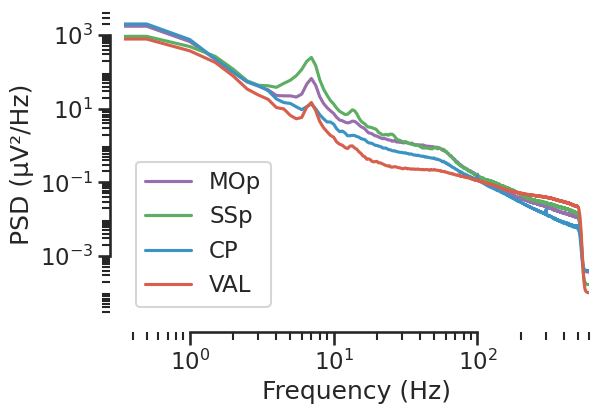

In [52]:
areas = ['MOp', 'SSp', 'CP', 'VAL']
with vizutils.apply_plot_style('talk'):
    fig, ax = plt.subplots(figsize=(6, 4))
    data = {}
    for area in areas:
        ax.loglog(f, Pxx[area].mean(axis=-1), label=area, color=getattr(colors, f"{area}_light"))
    ax.set_xlim(0, 600)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (µV²/Hz)")
    ax.legend()
# plt.title(f"Area: {area}")
plt.show()

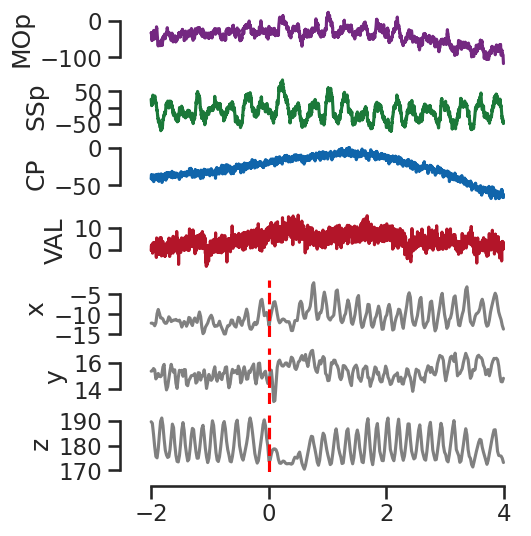

In [75]:
areas = ['MOp', 'SSp', 'CP', 'VAL']
times = np.linspace(-2, 4, 600)
with vizutils.apply_plot_style():
    fig, axs = plt.subplots(7, 1, figsize=(5, 6))

    for area, ax in zip(areas, axs):
        ax.plot(df_lfp[f"{area}_rates"].values[1][:, 0], color=getattr(colors, area))
        ax.set_ylabel(area)

    for i, ax, dim in zip(range(3), axs[4:], ['x', 'y', 'z']):
        ax.plot(times[::2], df_lfp.bhv.values[1][:, i][::2], color='grey')
        ax.set_ylabel(dim)
        ax.axvline(0, color='red', linestyle='dashed')
plt.show()



## Regression

In [5]:
data = {}
freqs = [
    ('delta', (0.5, 4), 2),
    ('theta', (4, 8), 2),
    ('alpha', (8, 12), 3),
    ('beta', (12, 30), 3),
    ('l_gamma', (30, 60), 4),
    ('h_gamma', (60, 250), 4),
    ('MUA', (250, 600), 4)
]
areas = ['MOp', 'SSp', 'CP', 'VAL']
for area in areas:
    print(f"Processing area: {area}")
    band_pass_power = {}
    for freq, freq_range, order in tqdm(freqs):
        # print(f"\tProcessing freq: {freq}")
        band_pass_power[freq] = []
        for trial in df_lfp[f"{area}_rates"].values:
            trial_power_signal = dsp.get_power_in_freq_range(
                trial,
                fs=sfreq,
                freqs=freq_range,
                order=order
            )
            band_pass_power[freq].append(trial_power_signal)
        band_pass_power[freq] = np.array(band_pass_power[freq])
    data[area] = band_pass_power

Processing area: MOp


  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:38<00:00,  5.54s/it]


Processing area: SSp


100%|██████████| 7/7 [00:28<00:00,  4.11s/it]


Processing area: CP


100%|██████████| 7/7 [01:06<00:00,  9.51s/it]


Processing area: VAL


100%|██████████| 7/7 [00:36<00:00,  5.16s/it]


In [6]:
# Assign data to dataframe
for area in areas:
    for freq, _, _ in freqs:
        df_lfp[f"{area}_{freq}"] = np.array
        for idx, _ in df_lfp.iterrows():
            # print(idx)
            trial = data[area][freq][idx]
            df_lfp[f"{area}_{freq}"].at[idx] = trial

In [7]:

# Get behaviour and downsample to 20ms bins
df_bhv_ = pyal.restrict_to_interval(df_bhv_spikes, 'idx_sol_on', rel_start=-100, rel_end=199)
bhv = np.concatenate(df_bhv_.bhv.values)
bhv = bhv[19:, :][::2]
n_timepoints, n_keypoints = bhv.shape
print(f"Windows: {n_timepoints}, keypoints: {n_keypoints}")

scores_lfps = {}
for area in areas:
    # Get areas
    cols = [col for col in df_lfp.columns if col.startswith(area)]
    cols.remove(f'{area}_rates')

    area_data = []
    for col in cols:
        area_data.append(np.concatenate(df_lfp[col].values).mean(axis=-1))
    area_data = np.array(area_data).T

    area_data = dsp.rolling_window(area_data, window_size=250, step=25)  # 500 ms rolling windows with 20 ms steps
    n_windows, n_channels, window_length = area_data.shape

    print(f"Area: {area}. Windows: {n_windows}, freqs: {n_channels}, window length: {window_length}")

    X = area_data.reshape(n_windows, -1)
    scores_lfps[area] = cross_val_score(Ridge(alpha=100), X, bhv, cv=4, scoring=decode.get_custom_scorer())



Windows: 53991, keypoints: 62
Area: MOp. Windows: 53991, freqs: 7, window length: 250
Area: SSp. Windows: 53991, freqs: 7, window length: 250
Area: CP. Windows: 53991, freqs: 7, window length: 250
Area: VAL. Windows: 53991, freqs: 7, window length: 250


In [8]:

# Get behaviour and downsample to 20ms bins
df_bhv_ = pyal.restrict_to_interval(df_bhv_spikes, 'idx_sol_on', rel_start=-100, rel_end=199)
bhv = np.concatenate(df_bhv_.bhv.values)
bhv = bhv[19:, :][::2]
n_timepoints, n_keypoints = bhv.shape
print(f"Windows: {n_timepoints}, keypoints: {n_keypoints}")

scores_spikes = {}
for area in areas:
    print(area)
    X_ = np.concatenate(df_bhv_[f"{area}_rates_pca"].values)
    X_ = X_[19:, :][::2]
    scores_spikes[area] = cross_val_score(Ridge(alpha=100), X_, bhv, cv=4, scoring=decode.get_custom_scorer())

Windows: 53991, keypoints: 62
MOp
SSp
CP
VAL


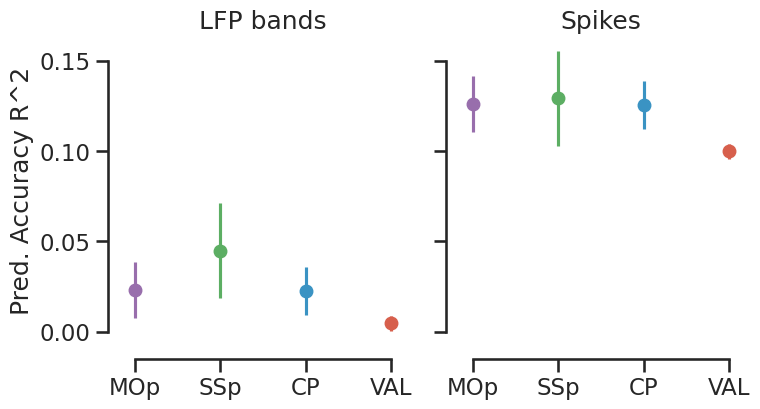

In [14]:
with vizutils.apply_plot_style():
    fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey='all')
    for area in areas:
        ax[0].errorbar(area, scores_lfps[area].mean(), fmt='o', yerr=scores_lfps[area].std(), 
                    color=getattr(colors, f"{area}_light"))
        ax[0].set_ylabel('Pred. Accuracy R^2')
        ax[0].set_title('LFP bands')
        ax[1].errorbar(area, scores_spikes[area].mean(), fmt='o', yerr=scores_lfps[area].std(), 
                    color=getattr(colors, f"{area}_light"))
        ax[1].set_title('Spikes')
plt.show()

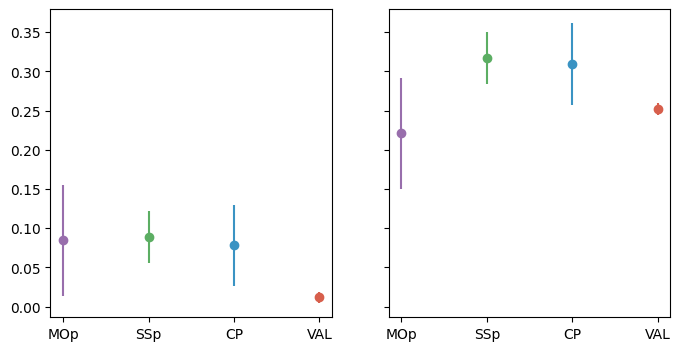

In [201]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey='all')
for area in areas:
    ax[0].errorbar(area, scores_lfps[area].mean(), fmt='o', yerr=scores_lfps[area].std(), 
                   color=getattr(colors, f"{area}_light"))
    ax[1].errorbar(area, scores_spikes[area].mean(), fmt='o', yerr=scores_lfps[area].std(), 
                   color=getattr(colors, f"{area}_light"))
plt.show()

In [148]:
y_pred = cross_val_predict(Ridge(alpha=100), X, bhv, cv=4)

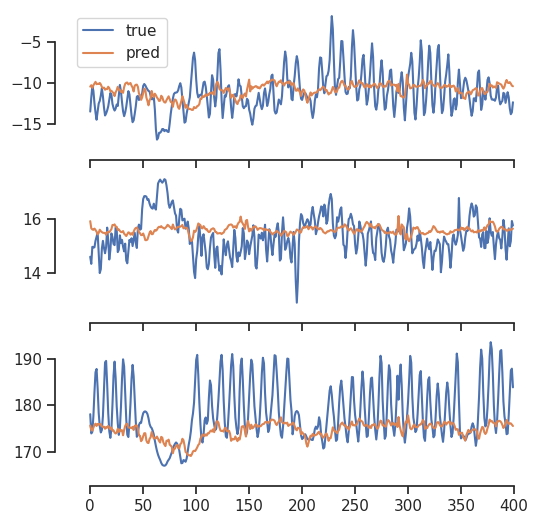

In [152]:
keypoints = 3
with vizutils.apply_plot_style('notebook'):
    fig, axs = plt.subplots(keypoints, 1, figsize=(6, 6), sharex='all')
    for ax, keypoint in zip(axs, range(keypoints)):
        ax.plot(bhv[:4*100, keypoint], label='true')
        ax.plot(y_pred[:4*100, keypoint], label='pred')
    axs[0].legend()

plt.show()

<Figure size 640x480 with 0 Axes>

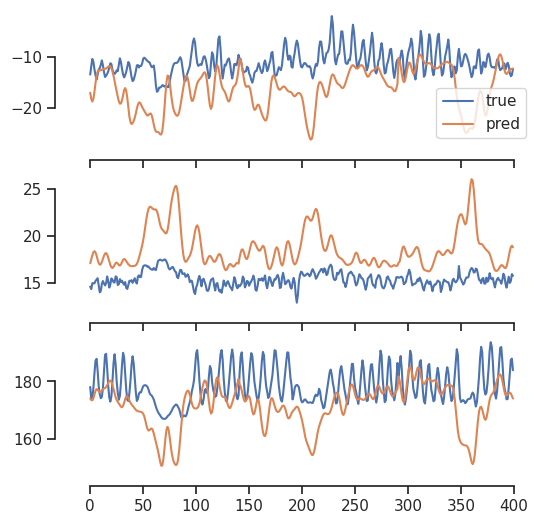

In [179]:
y_pred = cross_val_predict(Ridge(alpha=100), X_, bhv, cv=4)
keypoints = 3
with vizutils.apply_plot_style('notebook'):
    fig, axs = plt.subplots(keypoints, 1, figsize=(6, 6), sharex='all')
    for ax, keypoint in zip(axs, range(keypoints)):
        ax.plot(bhv[:4*100, keypoint], label='true')
        ax.plot(y_pred[:4*100, keypoint], label='pred')
    axs[0].legend()

plt.show()
